<a href="https://colab.research.google.com/github/SamipTmg614/lstm_translator/blob/main/lstm_en_to_nep.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

##this File tries to implement architecture proposed by Ilya sutskever for seq to sequence Learning to translate from english to nepali

In [1]:
!pip install -q datasets sacrebleu

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 100.8/100.8 kB 7.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 129.6/129.6 kB 16.2 MB/s eta 0:00:00


In [2]:
from datasets import load_dataset
ds = load_dataset("Helsinki-NLP/opus-100", "en-ne")
print(ds)

README.md:   0%|          | 0.00/65.4k [00:00<?, ?B/s]

en-ne/test-00000-of-00001.parquet: reconstructing file:   0%|          |  0.00B / 93.5kB            

en-ne/test-00000-of-00001.parquet: downloading bytes:           |  0.00B            

en-ne/train-00000-of-00001.parquet: reconstructing file:   0%|          |  0.00B / 23.9MB            

en-ne/train-00000-of-00001.parquet: downloading bytes:           |  0.00B            

...

en-ne/validation-00000-of-00001.parquet: downloading bytes:           |  0.00B            

Generating test split:   0%|          | 0/2000 [00:00<?, ? examples/s]

Generating train split:   0%|          | 0/406381 [00:00<?, ? examples/s]

Generating validation split:   0%|          | 0/2000 [00:00<?, ? examples/s]

DatasetDict({
    test: Dataset({
        features: ['translation'],
        num_rows: 2000
    })
    train: Dataset({
        features: ['translation'],
        num_rows: 406381
    })
    validation: Dataset({
        features: ['translation'],
        num_rows: 2000
    })
})


In [4]:
seen, pairs_raw = set(), []
for split in ("train", "validation", "test"):
    for ex in ds[split]:
        en = ex["translation"]["en"].strip().replace("\t", " ")
        ne = ex["translation"]["ne"].strip().replace("\t", " ")
        if not en or not ne or (en, ne) in seen:       # drop empties / exact duplicates
            continue
        seen.add((en, ne))
        pairs_raw.append((en, ne))

print(len(pairs_raw), "pairs")
for en, ne in pairs_raw[:10]:
    print(en, "->", ne)

148110 pairs
_Inv -> Inv
Voronezh -> भोरोनेज
Pixels above lines set -> मिलेका रेखाहरुको माथि पिक्सलहरु
‡ (#8225;) Double Dagger -> ‡ (# 8225;) डबल ड्यागर
Database -> डेटाबेसStencils
The clipboard could not be Signed. -> क्लिपबोर्ड साइन गर्न सकिएन ।
3rd -> तेस्रो
Editor navigations -> सम्पादक नेभिगेसन
S_ubject: -> विषय:
Cocoa -> कोकोबिच


In [5]:
import random, re, time
from collections import Counter
from types import SimpleNamespace

import torch
import torch.nn as nn
from torch.nn.utils.rnn import pack_padded_sequence, pad_sequence
from torch.utils.data import DataLoader, Dataset

PAD, SOS, EOS, UNK = 0, 1, 2, 3
SPECIALS = ["<pad>", "<sos>", "<eos>", "<unk>"]

TOKEN_RE = re.compile(r"[\w\u0900-\u0963\u0966-\u097F]+|[^\w\s]")

def tokenize(text):
    return TOKEN_RE.findall(text.lower())


In [6]:

class Vocab:
    def __init__(self, sentences, max_size, min_freq=2):
        counts = Counter(w for s in sentences for w in s)
        words = [w for w, c in counts.most_common(max_size - len(SPECIALS)) if c >= min_freq]
        self.itos = SPECIALS + words
        self.stoi = {w: i for i, w in enumerate(self.itos)}

    def encode(self, tokens):
        return [self.stoi.get(t, UNK) for t in tokens]

    def decode(self, ids):
        return [self.itos[i] for i in ids if i > UNK]      # drop special tokens

    def __len__(self):
        return len(self.itos)



In [7]:

class TranslationDataset(Dataset):
    def __init__(self, pairs, src_vocab, tgt_vocab):
        self.items = []
        for src, tgt in pairs:
            s = src_vocab.encode(src)[::-1] + [EOS]          # reverse the source, add <EOS>
            t = [SOS] + tgt_vocab.encode(tgt) + [EOS]         # target keeps its order
            self.items.append((torch.tensor(s), torch.tensor(t)))

    def __len__(self):
        return len(self.items)

    def __getitem__(self, i):
        return self.items[i]



In [8]:

def collate(batch):
    src, tgt = zip(*batch)
    src_len = torch.tensor([len(s) for s in src])
    src = pad_sequence(src, batch_first=True, padding_value=PAD)
    tgt = pad_sequence(tgt, batch_first=True, padding_value=PAD)
    return src, src_len, tgt

In [9]:
class Seq2Seq(nn.Module):
    def __init__(self, src_vocab, tgt_vocab, emb, hid, layers, dropout):
        super().__init__()
        self.src_emb = nn.Embedding(src_vocab, emb, padding_idx=PAD)
        self.tgt_emb = nn.Embedding(tgt_vocab, emb, padding_idx=PAD)
        lstm_drop = dropout if layers > 1 else 0.0
        self.encoder = nn.LSTM(emb, hid, layers, batch_first=True, dropout=lstm_drop)
        self.decoder = nn.LSTM(emb, hid, layers, batch_first=True, dropout=lstm_drop)
        self.out = nn.Linear(hid, tgt_vocab)
        self.drop = nn.Dropout(dropout)
        for p in self.parameters():                       # paper: U(-0.08, 0.08)
            nn.init.uniform_(p, -0.08, 0.08)

    def encode(self, src, src_len):
        x = self.drop(self.src_emb(src))
        packed = pack_padded_sequence(x, src_len.cpu(), batch_first=True, enforce_sorted=False)
        _, state = self.encoder(packed)                   # (h_n, c_n) = the "thought vector"
        return state

    def forward(self, src, src_len, tgt_in):
        state = self.encode(src, src_len)
        out, _ = self.decoder(self.drop(self.tgt_emb(tgt_in)), state)   # teacher forcing
        return self.out(out)

In [10]:
def run_epoch(model, loader, criterion, device, optimizer=None, clip=5.0):
    train = optimizer is not None
    model.train(train)
    total, batches = 0.0, 0
    with torch.set_grad_enabled(train):
        for src, src_len, tgt in loader:
            src, tgt = src.to(device), tgt.to(device)
            tgt_in, tgt_out = tgt[:, :-1], tgt[:, 1:]
            logits = model(src, src_len, tgt_in)
            loss = criterion(logits.reshape(-1, logits.size(-1)), tgt_out.reshape(-1))
            if train:
                optimizer.zero_grad()
                loss.backward()
                nn.utils.clip_grad_norm_(model.parameters(), clip)
                optimizer.step()
            total += loss.item()
            batches += 1
    return total / batches


@torch.no_grad()
def translate(model, sentence, src_vocab, tgt_vocab, device, beam=5, max_len=40):
    """Beam search. beam=1 is greedy decoding."""
    model.eval()
    ids = src_vocab.encode(tokenize(sentence))[::-1] + [EOS]
    src = torch.tensor([ids], device=device)
    state = model.encode(src, torch.tensor([len(ids)]))

    beams = [(0.0, [SOS], state)]                         # (log-prob, tokens, decoder state)
    finished = []
    for _ in range(max_len):
        candidates = []
        for score, seq, st in beams:
            inp = torch.tensor([[seq[-1]]], device=device)
            out, new_st = model.decoder(model.tgt_emb(inp), st)
            logp = torch.log_softmax(model.out(out[:, -1]), dim=-1).squeeze(0)
            top_lp, top_id = logp.topk(beam)
            for lp, i in zip(top_lp.tolist(), top_id.tolist()):
                candidates.append((score + lp, seq + [i], new_st))
        candidates.sort(key=lambda c: c[0], reverse=True)
        beams = []
        for cand in candidates[:beam]:
            (finished if cand[1][-1] == EOS else beams).append(cand)
        if not beams or len(finished) >= beam:
            break
    finished = finished or beams
    best = max(finished, key=lambda c: c[0] / len(c[1]))   # length-normalised score
    return " ".join(tgt_vocab.decode(best[1]))

In [13]:
cfg = SimpleNamespace(
    limit=None,        # use only the first N pairs (None = all)
    max_len=20,        # drop sentences longer than this many tokens
    vocab=16000,
    emb=256, hid=1000, layers=4, dropout=0.2,
    batch=128, epochs=8, lr=1e-3,
    sgd=True,
    beam=5,
)

In [12]:
random.seed(0)
torch.manual_seed(0)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("device:", device)

pairs = []
for en, ne in pairs_raw[:cfg.limit] if cfg.limit else pairs_raw:
    s, t = tokenize(en), tokenize(ne)
    if 0 < len(s) <= cfg.max_len and 0 < len(t) <= cfg.max_len:
        pairs.append((s, t))

random.shuffle(pairs)
val_pairs, train_pairs = pairs[:1000], pairs[1000:]
print(f"{len(train_pairs)} train pairs, {len(val_pairs)} val pairs")

src_vocab = Vocab([s for s, _ in train_pairs], cfg.vocab)
tgt_vocab = Vocab([t for _, t in train_pairs], cfg.vocab)
print(f"vocab sizes: src {len(src_vocab)}, tgt {len(tgt_vocab)}")

train_dl = DataLoader(TranslationDataset(train_pairs, src_vocab, tgt_vocab),
                      batch_size=cfg.batch, shuffle=True, collate_fn=collate)
val_dl = DataLoader(TranslationDataset(val_pairs, src_vocab, tgt_vocab),
                    batch_size=cfg.batch, collate_fn=collate)

device: cuda
140068 train pairs, 1000 val pairs
vocab sizes: src 16000, tgt 16000


In [ ]:
model = Seq2Seq(len(src_vocab), len(tgt_vocab), cfg.emb, cfg.hid, cfg.layers, cfg.dropout).to(device)
print(f"parameters: {sum(p.numel() for p in model.parameters()):,}")

lr = 0.7 if cfg.sgd else cfg.lr
optimizer = (torch.optim.SGD if cfg.sgd else torch.optim.Adam)(model.parameters(), lr=lr)
criterion = nn.CrossEntropyLoss(ignore_index=PAD)

demo = ["I am cold.", "Where is the station?", "Tom is my friend.", "I love you."]

for epoch in range(1, cfg.epochs + 1):
    if cfg.sgd and epoch > 5:
        for g in optimizer.param_groups:
            g["lr"] /= 2
    t0 = time.time()
    tr = run_epoch(model, train_dl, criterion, device, optimizer)
    va = run_epoch(model, val_dl, criterion, device)
    print(f"epoch {epoch:2d} | train loss {tr:.3f} | val loss {va:.3f} "
          f"(ppl {torch.exp(torch.tensor(va)):.1f}) | {time.time() - t0:.0f}s")
    for s in demo[:2]:
        print(f"    {s}  ->  {translate(model, s, src_vocab, tgt_vocab, device, cfg.beam)}")
    torch.save({"model": model.state_dict(), "src_itos": src_vocab.itos,
                "tgt_itos": tgt_vocab.itos, "cfg": vars(cfg)}, "seq2seq_lstm_3.pt")
print("saved seq2seq_lstm_3.pt")

parameters: 82,320,000
epoch  1 | train loss 5.732 | val loss 5.165 (ppl 175.1) | 322s
    I am cold.  ->  
    Where is the station?  ->  
epoch  2 | train loss 5.146 | val loss 5.002 (ppl 148.7) | 373s
    I am cold.  ->  नयाँ . .
    Where is the station?  ->  यो गरिएको गर्न गर्न
epoch  3 | train loss 4.755 | val loss 4.483 (ppl 88.5) | 372s
    I am cold.  ->  . kgm
    Where is the station?  ->  यो गरिएको बचत गर्नुहुन्छ ?
epoch  4 | train loss 4.394 | val loss 4.158 (ppl 63.9) | 372s
    I am cold.  ->  . kgm
    Where is the station?  ->  यो अवस्थित अवस्थित छ ?
epoch  5 | train loss 4.135 | val loss 4.068 (ppl 58.5) | 371s
    I am cold.  ->  ।
    Where is the station?  ->  फाइल लागि नै छ ?


In [ ]:
import sacrebleu

hyps, refs = [], []
for src, tgt in val_pairs[:300]:
    hyps.append(translate(model, " ".join(src), src_vocab, tgt_vocab, device, cfg.beam))
    refs.append(" ".join(tgt))
print(f"BLEU on 300 validation sentences: {sacrebleu.corpus_bleu(hyps, [refs]).score:.1f}")

print()
for s in demo + ["What is your name?", "Thank you very much.", "Good morning."]:
    print(s, "->", translate(model, s, src_vocab, tgt_vocab, device, cfg.beam))

BLEU on 300 validation sentences: 25.1

I am cold. -> म a
Where is the station? -> कहाँ हो ?
Tom is my friend. -> मेरो मेरो छ ।
I love you. -> तपाईँले लगइन गर्नुभयो ।
What is your name? -> तपाईँको कुन नाम हो ?
Thank you very much. -> ठीक छ ।
Good morning. -> उत्तम


result with 2 layers and 15 epochs

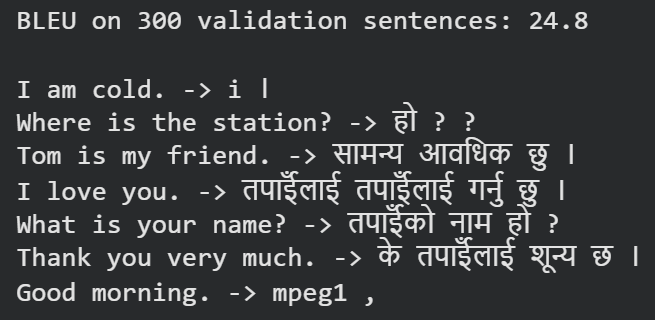

In [ ]:
while True:
    s = input("English > ").strip()
    if not s:
        break
    print("Nepali  >", translate(model, s, src_vocab, tgt_vocab, device, cfg.beam))

English > hi


NameError: name 'translate' is not defined

In [ ]:
from google.colab import drive
drive.mount('/content/drive')
!cp seq2seq_lstm.pt /content/drive/MyDrive/